# Partie 1 - Exploration et prétraitement des données 

* Imports et chargement

In [1]:
import sys
!{sys.executable} -m pip install seaborn wordcloud nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

df = pd.read_csv('tweets_suspect.csv')

print("Shape:", df.shape)
print(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Shape: (60000, 2)
                                             message  label
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...      1
1  is upset that he can't update his Facebook by ...      1
2  @Kenichan I dived many times for the ball. Man...      1
3    my whole body feels itchy and like its on fire       0
4  @nationwideclass no, it's not behaving at all....      1


* Analyse exploratoire

=== Valeurs manquantes ===
message    0
label      0
dtype: int64

=== Distribution des classes ===
label
1    53855
0     6145
Name: count, dtype: int64


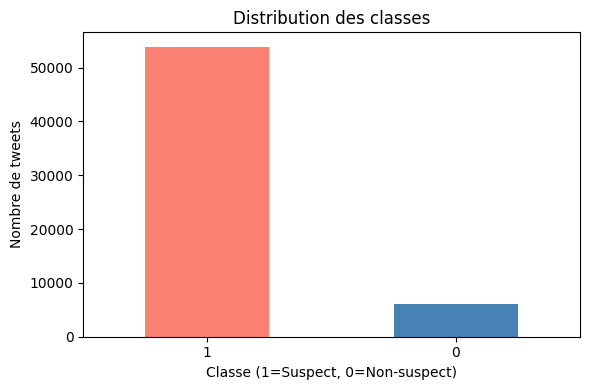

In [3]:
# Valeurs manquantes
print("=== Valeurs manquantes ===")
print(df.isnull().sum())

# Distribution des classes
print("\n=== Distribution des classes ===")
print(df['label'].value_counts())

# Visualisation
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title("Distribution des classes")
plt.xlabel("Classe (1=Suspect, 0=Non-suspect)")
plt.ylabel("Nombre de tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("distribution_classes.png")
plt.show()

* Longueur des tweets

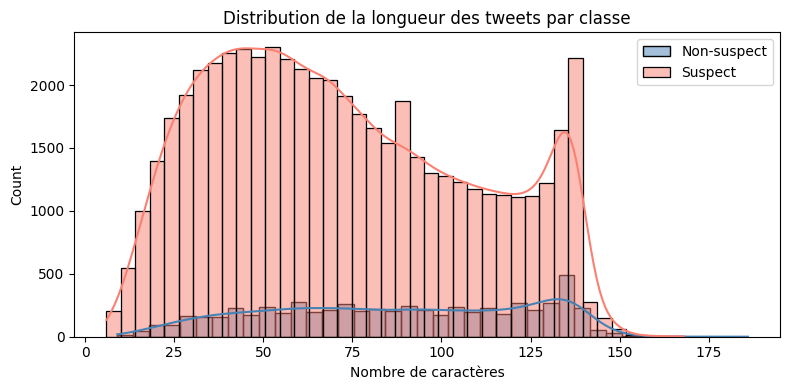

In [4]:
df['tweet_length'] = df['message'].apply(len)

plt.figure(figsize=(8, 4))
for label, color in zip([0, 1], ['steelblue', 'salmon']):
    subset = df[df['label'] == label]['tweet_length']
    sns.histplot(subset, label=f"{'Suspect' if label==1 else 'Non-suspect'}",
                 kde=True, bins=40, color=color)

plt.title("Distribution de la longueur des tweets par classe")
plt.xlabel("Nombre de caractères")
plt.legend()
plt.tight_layout()
plt.savefig("longueur_tweets.png")
plt.show()

* WordCloud

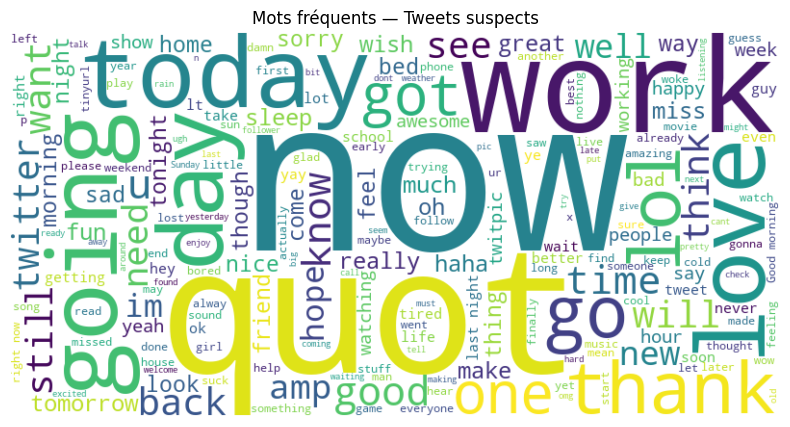

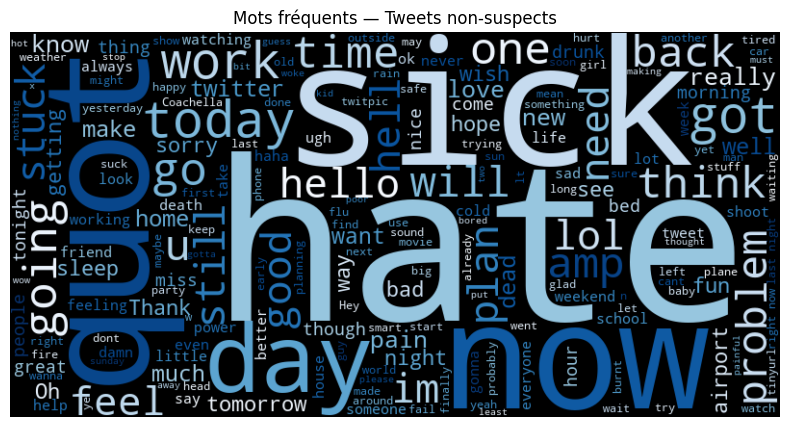

In [5]:
# Tweets suspects
suspects = ' '.join(df[df['label'] == 1]['message'].astype(str))
wc_suspect = WordCloud(width=800, height=400, background_color='white').generate(suspects)

plt.figure(figsize=(10, 5))
plt.imshow(wc_suspect, interpolation='bilinear')
plt.axis('off')
plt.title("Mots fréquents — Tweets suspects")
plt.savefig("wordcloud_suspects.png")
plt.show()

# Tweets non-suspects
non_suspects = ' '.join(df[df['label'] == 0]['message'].astype(str))
wc_normal = WordCloud(width=800, height=400, background_color='black', colormap='Blues').generate(non_suspects)

plt.figure(figsize=(10, 5))
plt.imshow(wc_normal, interpolation='bilinear')
plt.axis('off')
plt.title("Mots fréquents — Tweets non-suspects")
plt.savefig("wordcloud_non_suspects.png")
plt.show()

* Prétraitement

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)                  # mentions @
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # caractères spéciaux
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['text_clean'] = df['message'].apply(preprocess)

# Sauvegarder le dataset prétraité
df.to_csv('tweets_preprocessed.csv', index=False)

print("Prétraitement terminé !")
print("\nAvant :", df['message'].iloc[0])
print("Après :", df['text_clean'].iloc[0])

Prétraitement terminé !

Avant : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Après : thats bummer shoulda got david carr third day


# Partie 2 - Gestion des données avec DVC 

# Partie 3 - Représentation des données 

* Chargement des données prétraitées

In [7]:
import sys
!{sys.executable} -m pip install gensim

In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pickle

df = pd.read_csv('data/tweets_preprocessed.csv')
df['text_clean'] = df['text_clean'].fillna('')

print("Shape:", df.shape)
print(df.head())

Shape: (60000, 3)
                                             message  label  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...      1   
1  is upset that he can't update his Facebook by ...      1   
2  @Kenichan I dived many times for the ball. Man...      1   
3    my whole body feels itchy and like its on fire       0   
4  @nationwideclass no, it's not behaving at all....      1   

                                          text_clean  
0      thats bummer shoulda got david carr third day  
1  upset cant update facebook texting might cry r...  
2    dived many time ball managed save rest go bound  
3                    whole body feel itchy like fire  
4                           behaving im mad cant see  


* TF-IDF

In [16]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['text_clean'])

print("Shape TF-IDF:", X_tfidf.shape)

# Sauvegarder le vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Sauvegarder la matrice
np.save('models/X_tfidf.npy', X_tfidf.toarray())

print("TF-IDF terminé et sauvegardé !")

Shape TF-IDF: (60000, 5000)
TF-IDF terminé et sauvegardé !


* Word2Vec

In [17]:
# Tokeniser les tweets
sentences = [text.split() for text in df['text_clean']]

# Entraîner Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

# Sauvegarder le modèle Word2Vec
w2v_model.save('models/word2vec.model')
print("Word2Vec entraîné et sauvegardé !")

# Transformer chaque tweet en vecteur (moyenne des mots)
def tweet_to_vector(text, model, vector_size=100):
    words = text.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X_w2v = np.array([tweet_to_vector(text, w2v_model) for text in df['text_clean']])
np.save('models/X_w2v.npy', X_w2v)

print("Shape Word2Vec:", X_w2v.shape)
print("Vecteurs Word2Vec sauvegardés !")

Word2Vec entraîné et sauvegardé !
Shape Word2Vec: (60000, 100)
Vecteurs Word2Vec sauvegardés !


* Visualisation PCA

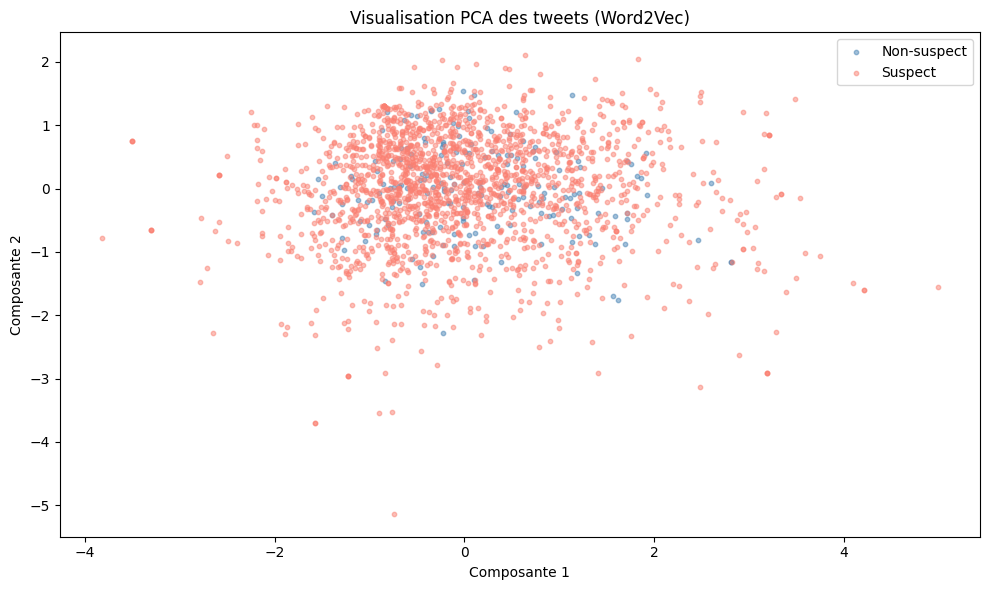

Visualisation PCA sauvegardée !


In [18]:
# Réduire à 2 dimensions avec PCA pour visualiser
pca = PCA(n_components=2)

# Échantillon de 2000 tweets pour la visualisation
sample_idx = np.random.choice(len(X_w2v), 2000, replace=False)
X_sample = X_w2v[sample_idx]
y_sample = df['label'].values[sample_idx]

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
colors = {0: 'steelblue', 1: 'salmon'}
labels = {0: 'Non-suspect', 1: 'Suspect'}

for label in [0, 1]:
    mask = y_sample == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[label], label=labels[label],
                alpha=0.5, s=10)

plt.title("Visualisation PCA des tweets (Word2Vec)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()
plt.tight_layout()
plt.savefig("pca_word2vec.png")
plt.show()
print("Visualisation PCA sauvegardée !")

* Commit Git

In [19]:
import subprocess
subprocess.run(['git', 'add', '.'], check=True)
subprocess.run(['git', 'commit', '-m', 'Partie 3 : TF-IDF + Word2Vec + PCA'], check=True)
print("Commit fait !")

Commit fait !


# Partie 4 - Construction des modèles 

*  Imports et chargement

In [21]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---

In [23]:
pip install xgboost imbalanced-learn scikit-learn pandas numpy


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

# Charger les données
df = pd.read_csv('data/tweets_preprocessed.csv')
df['text_clean'] = df['text_clean'].fillna('')

# Charger la matrice TF-IDF
X = np.load('models/X_tfidf.npy')
y = df['label'].values

print("Shape X:", X.shape)
print("Distribution classes:", dict(zip(*np.unique(y, return_counts=True))))

Shape X: (60000, 5000)
Distribution classes: {np.int64(0): np.int64(6145), np.int64(1): np.int64(53855)}


*  Split train/test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (48000, 5000)
Test: (12000, 5000)


* Gestion du déséquilibre avec SMOTE

In [26]:
print("Avant SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Après SMOTE:", dict(zip(*np.unique(y_train_bal, return_counts=True))))
print(" SMOTE appliqué !")

Avant SMOTE: {np.int64(0): np.int64(4916), np.int64(1): np.int64(43084)}
Après SMOTE: {np.int64(0): np.int64(43084), np.int64(1): np.int64(43084)}
✅ SMOTE appliqué !


* Logistic Regression

In [27]:
print("Entraînement Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Non-suspect', 'Suspect']))

results = {}
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr)
}
print(" Logistic Regression terminé !")

Entraînement Logistic Regression...

=== Logistic Regression ===
              precision    recall  f1-score   support

 Non-suspect       0.57      0.78      0.66      1229
     Suspect       0.97      0.93      0.95     10771

    accuracy                           0.92     12000
   macro avg       0.77      0.86      0.81     12000
weighted avg       0.93      0.92      0.92     12000

 Logistic Regression terminé !


* Random Forest

In [28]:
print("Entraînement Random Forest ...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Non-suspect', 'Suspect']))

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf)
}
print("Random Forest terminé !")

Entraînement Random Forest ...

=== Random Forest ===
              precision    recall  f1-score   support

 Non-suspect       0.69      0.66      0.68      1229
     Suspect       0.96      0.97      0.96     10771

    accuracy                           0.94     12000
   macro avg       0.83      0.81      0.82     12000
weighted avg       0.93      0.94      0.93     12000

Random Forest terminé !


* XGBoost

In [29]:
print("Entraînement XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_bal)

y_pred_xgb = xgb.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-suspect', 'Suspect']))

results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb)
}
print("XGBoost terminé !")

Entraînement XGBoost...

=== XGBoost ===
              precision    recall  f1-score   support

 Non-suspect       0.93      0.75      0.83      1229
     Suspect       0.97      0.99      0.98     10771

    accuracy                           0.97     12000
   macro avg       0.95      0.87      0.91     12000
weighted avg       0.97      0.97      0.97     12000

XGBoost terminé !


* Comparaison des modèles

In [ ]:
import matplotlib.pyplot as plt

# Tableau comparatif
df_results = pd.DataFrame(results).T
print("\n=== Comparaison des modèles ===")
print(df_results.round(4))

# Visualisation
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (model, values) in enumerate(results.items()):
    ax.bar(x + i*width, [values[m] for m in metrics], width, label=model)

ax.set_xlabel('Métriques')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles')
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('comparaison_modeles.png')
plt.show()
print("Comparaison sauvegardée !")

* Sauvegarder le meilleur modèle

In [31]:
# Sauvegarder tous les modèles
with open('models/model_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('models/model_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('models/model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Sauvegarder le meilleur modèle (celui avec le meilleur F1)
best_model_name = df_results['f1'].idxmax()
print(f"Meilleur modèle : {best_model_name}")

best_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

with open('models/model.pkl', 'wb') as f:
    pickle.dump(best_models[best_model_name], f)

print("Meilleur modèle sauvegardé dans models/model.pkl !")

Meilleur modèle : XGBoost
Meilleur modèle sauvegardé dans models/model.pkl !


# ============================================================
# Partie 5 - Entraînement et validation
# ============================================================

* Validation croisée

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Validation croisée 5-fold sur le meilleur modèle (XGBoost)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validation croisée en cours...")

for model_name, model in [('Logistic Regression', lr), 
                            ('Random Forest', rf), 
                            ('XGBoost', xgb)]:
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    print(f"\n{model_name}:")
    print(f"  F1 par fold : {scores.round(4)}")
    print(f"  Moyenne     : {scores.mean():.4f} (+/- {scores.std():.4f})")

* Courbes d'apprentissage

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, model_name, X, y, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='f1', n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, label='Train', marker='o')
    plt.plot(train_sizes, val_mean, label='Validation', marker='s')
    plt.title(f"Courbe d'apprentissage - {model_name}")
    plt.xlabel("Taille du dataset d'entraînement")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid(True)

print("Génération des courbes (peut prendre 3-5 min)...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (model_name, model) in enumerate([('Logistic Regression', lr),
                                           ('Random Forest', rf),
                                           ('XGBoost', xgb)]):
    plt.sca(axes[i])
    plot_learning_curve(model, model_name, X, y, skf)

plt.tight_layout()
plt.savefig('courbes_apprentissage.png')
plt.show()
print("Courbes d'apprentissage sauvegardées !")